# Connexion Google Drive

In [13]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports Keras & Configuration

In [14]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# --- Paramètres modifiables ---
# Remplacez le chemin ci-dessous par celui où se situe votre dataset dans le Drive !
DATASET_PATH = "/content/drive/MyDrive/Distracted-Driver-Detection/Datasets/train_64x64.parquet"
IMG_SHAPE = (64, 64, 3)
BATCH_SIZE = 256
TOTAL_SAMPLES = 22424 # Nombre exact de vos images d'entraînement

print(f"TensorFlow {tf.__version__}")
print(f"   GPU disponible : {tf.config.list_physical_devices('GPU')}")


TensorFlow 2.19.0
   GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Pipeline de données

# Split Train et Val

### Cellule Annexe

[*] Chargement du Parquet en mémoire via PyArrow...
[*] 22424 images chargées !
[*] Reformatage des pixels en Tensors...

[*] TEST DU PIPELINE...
-> Shape du lot d'images généré : (3, 64, 64, 3) (Attendu: (3, 64, 64, 3))
-> Shape du lot de labels : (3,) (Attendu: (3,))


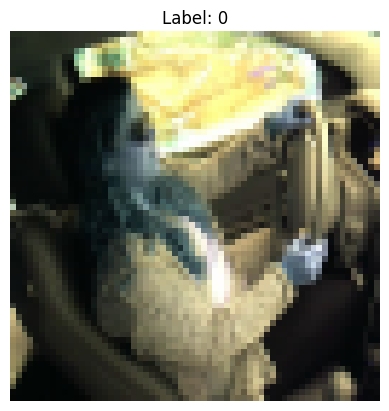

In [15]:
print("[*] Chargement du Parquet en mémoire via PyArrow...")
# On active la détection automatique des labels via les dossiers (Hive Partitioning)
dataset_pa = ds.dataset(DATASET_PATH, format="parquet", partitioning="hive")

# Conversion en DataFrame Pandas pour une manipulation ultra-facile
df = dataset_pa.to_table(columns=["pixels", "label"]).to_pandas()
TOTAL_SAMPLES = len(df)
print(f"[*] {TOTAL_SAMPLES} images chargées !")

print("[*] Reformatage des pixels en Tensors...")
# On convertit les lignes de pixels en une seule grosse matrice
X = np.stack(df['pixels'].values).reshape(-1, *IMG_SHAPE)
# On convertit la colonne de labels (catégorie extraite du nom du dossier) en entiers
y = df['label'].astype(int).values

# Création du Dataset TensorFlow natif final à partir de notre mémoire RAM
raw_dataset = tf.data.Dataset.from_tensor_slices((X, y))

# --- DEBUG ---
print("\n[*] TEST DU PIPELINE...")
for image_batch, label_batch in raw_dataset.batch(3).take(1):
    print(f"-> Shape du lot d'images généré : {image_batch.shape} (Attendu: (3, 64, 64, 3))")
    print(f"-> Shape du lot de labels : {label_batch.shape} (Attendu: (3,))")

    plt.imshow(image_batch[0].numpy())
    plt.title(f"Label: {label_batch[0].numpy()}")
    plt.axis("off")
    plt.show()

In [16]:
# Mettre en cache pour éviter de recharger le fichier distant à chaque Époque
cached_dataset = raw_dataset.cache()

# Mélanger les images avec une graine fixe (Seed) pour reproduire la division
shuffled_dataset = cached_dataset.shuffle(buffer_size=TOTAL_SAMPLES, seed=42, reshuffle_each_iteration=False)

# Nombre d'images pour le train (80%)
train_size = int(0.80 * TOTAL_SAMPLES)

# Création des deux jeux de données finaux
train_dataset = shuffled_dataset.take(train_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = shuffled_dataset.skip(train_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"[*] Division prête : {train_size} images d'entraînement, {TOTAL_SAMPLES - train_size} images de validation.")


[*] Division prête : 17939 images d'entraînement, 4485 images de validation.


## Vérification du dataset

[*] TEST DU PIPELINE DE LECTURE TF_IO...
Succès ! Pipeline fonctionnel.
-> Shape du lot d'images généré : (3, 64, 64, 3) (Attendu: (3, 128, 128, 3))
-> Shape du lot de labels : (3,) (Attendu: (3,))
-> Labels lus depuis les dossiers : [0 0 0]


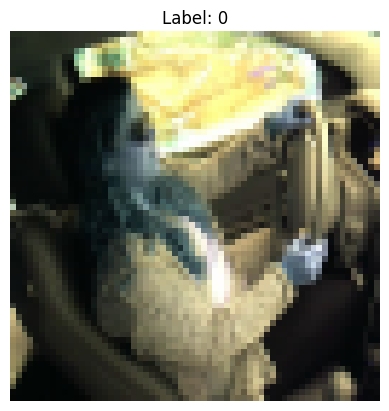

In [17]:
print("[*] TEST DU PIPELINE DE LECTURE TF_IO...")

# On demande formellement au pipeline de nous extraire 1 seul Tensor ("Take 1")
for image_batch, label_batch in raw_dataset.batch(3).take(1):
    print("Succès ! Pipeline fonctionnel.")
    print(f"-> Shape du lot d'images généré : {image_batch.shape} (Attendu: (3, 128, 128, 3))")
    print(f"-> Shape du lot de labels : {label_batch.shape} (Attendu: (3,))")
    print(f"-> Labels lus depuis les dossiers : {label_batch.numpy()}")

    # Affichage rapide de la première image du batch
    plt.imshow(image_batch[0].numpy())
    plt.title(f"Label: {label_batch[0].numpy()}")
    plt.axis("off")
    plt.show()


# Création du CNN

In [18]:
model = Sequential()

# Bloc 1
model.add(Conv2D(filters=64, kernel_size=2, padding='same', activation='relu', input_shape=IMG_SHAPE, kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))
# Bloc 2
model.add(Conv2D(filters=128, kernel_size=2, padding='same', activation='relu', kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))
# Bloc 3
model.add(Conv2D(filters=256, kernel_size=2, padding='same', activation='relu', kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))
# Bloc 4
model.add(Conv2D(filters=512, kernel_size=2, padding='same', activation='relu', kernel_initializer='glorot_normal'))
model.add(MaxPooling2D(pool_size=2))

model.add(Dropout(0.5))
model.add(Flatten())

# Classification
model.add(Dense(500, activation='relu', kernel_initializer='glorot_normal'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax', kernel_initializer='glorot_normal'))

# Compilation
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │     4,096,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,791,366 (18.28 MB)

 Trainable params: 4,791,366 (18.28 MB)

 Non-trainable params: 0 (0.00 B)

Training & Sauvegarde

In [19]:
# Ajout d'une sauvegarde automatique
from keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint('/content/drive/MyDrive/distracted_driver_cnn.keras', save_best_only=True, monitor='val_accuracy')

print("[*] Démarrage du CNN...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[checkpoint]
)


[*] Démarrage du CNN...
Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.4289 - loss: 1.5595 - val_accuracy: 0.6807 - val_loss: 0.8234
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8151 - loss: 0.5542 - val_accuracy: 0.9378 - val_loss: 0.2514
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9282 - loss: 0.2443 - val_accuracy: 0.9623 - val_loss: 0.1368
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9561 - loss: 0.1506 - val_accuracy: 0.9784 - val_loss: 0.0854
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9700 - loss: 0.0983 - val_accuracy: 0.9799 - val_loss: 0.0726
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9765 - loss: 0.0739 - val_accuracy: 0.9835 - val_loss: 0.0555
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9844 - loss: 0.0526 - val_accuracy: 0.9875 - val_loss: 0.0449
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9866 - loss: 0.0427 -

## Résultats

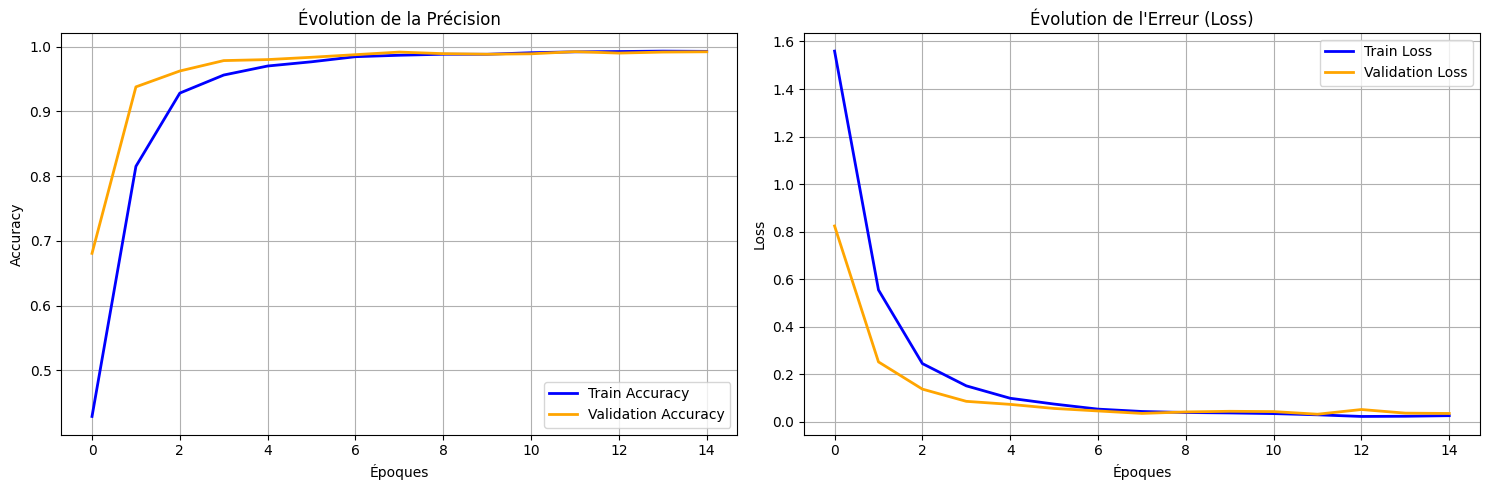

In [20]:
def plot_learning_curves(history):
    # Création d'une figure avec 2 graphiques (1 ligne, 2 colonnes)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    # 1. Graphique de l'Accuracy (Précision)
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    axes[0].set_title('Évolution de la Précision')
    axes[0].set_xlabel('Époques')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    # 2. Graphique de la Loss (Perte/Erreur)
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    axes[1].set_title('Évolution de l\'Erreur (Loss)')
    axes[1].set_xlabel('Époques')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()
# Affichage direct depuis la variable history de model.fit()
plot_learning_curves(history)

[*] Extraction des vrais labels et lancement des prédictions (rapide)...
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


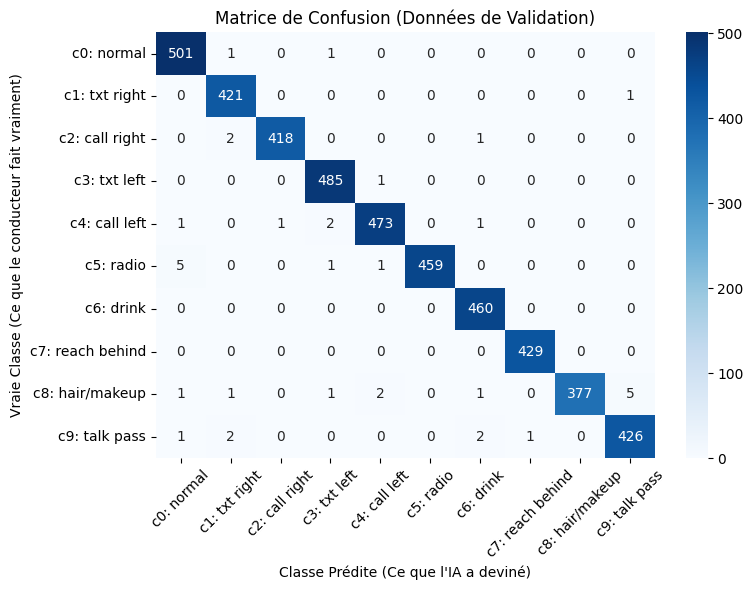


--- RAPPORT DE CLASSIFICATION DÉTAILLÉ ---
                  precision    recall  f1-score   support

      c0: normal       0.98      1.00      0.99       503
   c1: txt right       0.99      1.00      0.99       422
  c2: call right       1.00      0.99      1.00       421
    c3: txt left       0.99      1.00      0.99       486
   c4: call left       0.99      0.99      0.99       478
       c5: radio       1.00      0.98      0.99       466
       c6: drink       0.99      1.00      0.99       460
c7: reach behind       1.00      1.00      1.00       429
 c8: hair/makeup       1.00      0.97      0.99       388
   c9: talk pass       0.99      0.99      0.99       432

        accuracy                           0.99      4485
       macro avg       0.99      0.99      0.99      4485
    weighted avg       0.99      0.99      0.99      4485



In [21]:
print("[*] Extraction des vrais labels et lancement des prédictions (rapide)...")
# 1. On récupère la vérité absolue depuis notre "Robinet" de validation
y_true = np.concatenate([y.numpy() for _, y in val_dataset], axis=0)
# 2. On demande au GPU de prédire sur toutes les images
predictions_brutes = model.predict(val_dataset)
y_pred = np.argmax(predictions_brutes, axis=1)
# 3. Calcul de la Matrice de Confusion
cm = confusion_matrix(y_true, y_pred)
# Définition des 10 classes pour un affichage propre
class_names = [
    "c0: normal", "c1: txt right", "c2: call right",
    "c3: txt left", "c4: call left", "c5: radio",
    "c6: drink", "c7: reach behind", "c8: hair/makeup", "c9: talk pass"
]
# 4. Affichage du magnifique graphique Heatmap avec Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion (Données de Validation)')
plt.ylabel('Vraie Classe (Ce que le conducteur fait vraiment)')
plt.xlabel('Classe Prédite (Ce que l\'IA a deviné)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 5. Bonus : Bilan Statistique Global
print("\n--- RAPPORT DE CLASSIFICATION DÉTAILLÉ ---")
print(classification_report(y_true, y_pred, target_names=class_names))